In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [15]:
start, end = '2022-01-01', '2026-01-01'

close_prices = yf.download('SPY', start=start, end=end, interval='1d', auto_adjust=True)['Close']

print(f'Shape: {close_prices.shape}')
display(close_prices.head())
display(close_prices.describe())
display(close_prices.info())

# convert dataframe to series (use SPY for now)
close_prices = close_prices['SPY']

[*********************100%***********************]  1 of 1 completed

Shape: (1003, 1)


Ticker,SPY
Date,
2022-01-03,450.644409
2022-01-04,450.493469
2022-01-05,441.843018
2022-01-06,441.427979
2022-01-07,439.682831


Ticker,SPY
count,1003.000000
mean,486.070601
std,97.814340
min,340.252808
25%,397.364990
50%,461.188263
75%,569.474640
max,688.499695


<class 'pandas.DataFrame'>
DatetimeIndex: 1003 entries, 2022-01-03 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     1003 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


None

In [16]:
# derive 3 features (returns, volatility, drawdowns)

vol_window = 5          # 5-10 days is reactive and quick capturing day-to-day turbulence
drawdown_window = 60    # 60 days ~1 quarter and is cumulative capturing how far below meaningful recent high

log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
rolling_vol = close_prices.rolling(window=vol_window).std()
rolling_max = close_prices.rolling(window=drawdown_window).max()
drawdowns = (close_prices - rolling_max) / close_prices

features = pd.DataFrame({
    'log_return': log_returns,
    'rolling_vol': rolling_vol,
    'drawdown': drawdowns,
}).dropna()

print(f'Shape: {features.shape}')
display(features.head())
display(features.describe())
display(features.info())


Shape: (944, 3)


,log_return,rolling_vol,drawdown
Date,,,
2022-03-29,0.012295,6.214946,-0.031807
2022-03-30,-0.006194,4.214093,-0.037870
2022-03-31,-0.015511,3.902102,-0.039680
2022-04-01,0.002830,3.858105,-0.036742
2022-04-04,0.008530,3.864398,-0.027936


,log_return,rolling_vol,drawdown
count,944.000000,944.000000,944.000000
mean,0.000482,4.236316,-0.037573
std,0.011166,2.842896,0.051087
min,-0.060326,0.318056,-0.258830
25%,-0.004547,2.528674,-0.051500
50%,0.000671,3.562857,-0.014213
75%,0.006265,5.320341,-0.002564
max,0.099863,28.686818,0.000000


<class 'pandas.DataFrame'>
DatetimeIndex: 944 entries, 2022-03-29 to 2025-12-31
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_return   944 non-null    float64
 1   rolling_vol  944 non-null    float64
 2   drawdown     944 non-null    float64
dtypes: float64(3)
memory usage: 29.5 KB


None

In [17]:
# include specific input features
feature_cols = ['log_return', 'rolling_vol', 'drawdown']

# standardize feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

# fit hmm with 3 hidden states
model = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
model.fit(X_scaled)

print(f'Converged: {model.monitor_.converged}')
print(f'Log-likelihood: {model.score(X_scaled):.2f}')

# predict regimess
features['regime'] = model.predict(X_scaled)

print(f'\nRegime counts:\n{features['regime'].value_counts().sort_index()}')

display(features)

Converged: True
Log-likelihood: -2052.30

Regime counts:
regime
0    351
1    408
2    185
Name: count, dtype: int64


,log_return,rolling_vol,drawdown,regime
Date,,,,
2022-03-29,0.012295,6.214946,-0.031807,2
2022-03-30,-0.006194,4.214093,-0.037870,0
2022-03-31,-0.015511,3.902102,-0.039680,0
2022-04-01,0.002830,3.858105,-0.036742,0
2022-04-04,0.008530,3.864398,-0.027936,0
...,...,...,...,...
2025-12-24,0.003511,6.283038,0.000000,0
2025-12-26,-0.000101,4.139765,-0.000101,1
2025-12-29,-0.003570,2.269732,-0.003678,1


In [ ]:
regime_means = pd.DataFrame(
    scaler.inverse_transform(model.means_),
    columns=feature_cols,
    index=[f'Regime {i}' for i in range(model.n_components)]
)
display(regime_means.round(4))

regime_labels = {0: 'Chop', 1: 'Bull', 2: 'Bear'}
features['regime_label'] = features['regime'].map(regime_labels)

,log_return,rolling_vol,drawdown
State 0,-0.0003,4.5445,-0.0308
State 1,0.0016,2.7684,-0.0037
State 2,-0.0005,6.8870,-0.1245


Regime Duration Stats (trading days)


,min,max,mean,count
regime,,,,
Bear,1,66,30.8,6
Bull,2,64,18.5,22
Chop,1,56,13.0,27


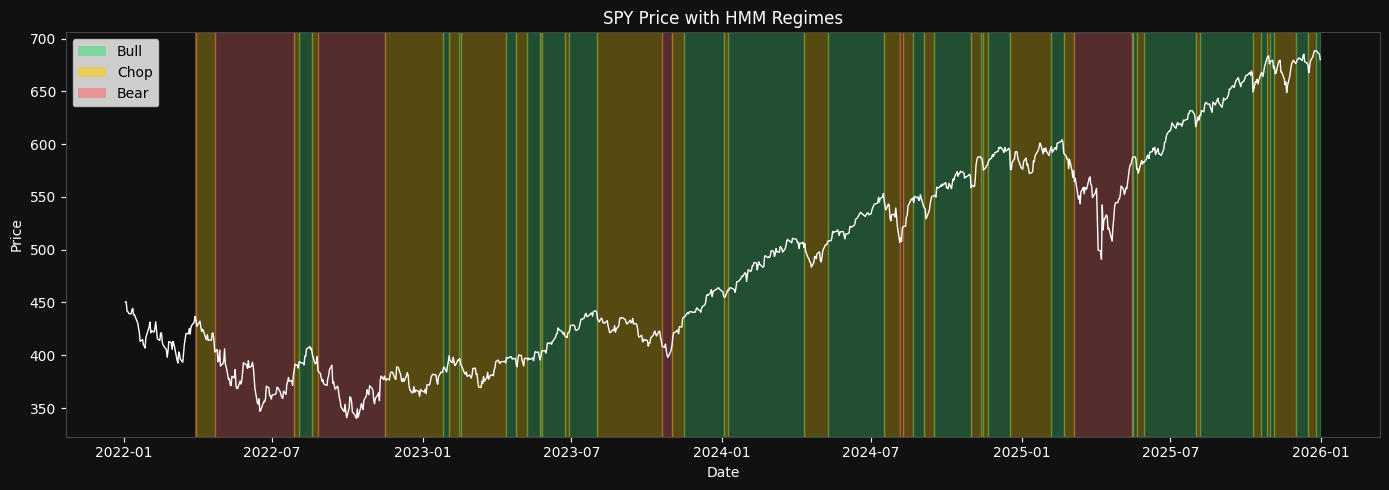

In [24]:
# regime duration analysis
# finds contiguous runs of the same regime and measures how long each lasts (in trading days)

runs = []
current = features['regime_label'].iloc[0]
count = 1

for label in features['regime_label'].iloc[1:]:
    if label == current:
        count += 1
    else:
        runs.append({'regime': current, 'duration': count})
        current = label
        count = 1
runs.append({'regime': current, 'duration': count})

runs_df = pd.DataFrame(runs)

print('Regime Duration Stats (trading days)')
display(runs_df.groupby('regime')['duration'].agg(['min', 'max', 'mean', 'count']).round(1))

# ------------------------------------------------
#             PLOT REGIMES
# ------------------------------------------------

regime_colors = {'Bull': '#4ade80', 'Chop': '#facc15', 'Bear': '#f87171'}

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_prices.index, close_prices, color='white', linewidth=1, zorder=2)

# shade regime regions
current_label = features['regime_label'].iloc[0]
start_idx = features.index[0]

for date, label in features['regime_label'].items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=regime_colors[current_label], alpha=0.3, zorder=1)
        current_label = label
        start_idx = date

ax.axvspan(start_idx, features.index[-1], color=regime_colors[current_label], alpha=0.3, zorder=1)

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=regime_colors[label], alpha=0.6, label=label) for label in regime_colors]
ax.legend(handles=legend_elements, loc='upper left')

ax.set_title('SPY Price with HMM Regimes')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')

plt.tight_layout()
plt.show()